# Comparison Baseline vs Counting Agents

Notebook 03 laedt die in Notebook 01 und 02 trainierten Agenten, testet sie unter denselben Bedingungen und vergleicht ihre Lernkurven.

## Loading the Trained Agents

In [1]:
from collections import defaultdict
from pathlib import Path
import pickle
import sys

import gymnasium as gym
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "blackjack_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from blackjack_env import BlackjackEnv


def baseline_state_key(obs) -> tuple[int, int, int]:
    player_total, dealer_upcard, usable_ace = obs[:3]
    return int(player_total), int(dealer_upcard), int(usable_ace)


def counting_state_key(obs) -> tuple[int, int, int, int, int, int]:
    player_total, dealer_upcard, usable_ace, running_count, true_count, cards_remaining = obs
    count_bucket = int(np.clip(np.round(running_count), -20, 20))
    true_count_bucket = int(np.clip(np.round(true_count), -10, 10))
    shoe_bucket = int(np.clip(np.round(cards_remaining / 52.0), 0, 6))
    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace),
        count_bucket,
        true_count_bucket,
        shoe_bucket,
    )


class QLearningAgent:
    def __init__(self, env: gym.Env, state_key_fn):
        self.env = env
        self.state_key_fn = state_key_fn
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

    def get_action(self, obs) -> int:
        state = self.state_key_fn(obs)
        return int(np.argmax(self.q_values[state]))


def load_agent_artifact(artifact_path: Path, env: gym.Env, state_key_fn):
    if not artifact_path.exists():
        raise FileNotFoundError(
            f"Missing saved agent artifact: {artifact_path}. Run notebooks 01_baseline.ipynb and 02_counting.ipynb first."
        )

    with artifact_path.open("rb") as file_handle:
        artifact = pickle.load(file_handle)

    agent = QLearningAgent(env, state_key_fn)
    for state, values in artifact["q_values"].items():
        agent.q_values[state] = np.array(values)

    return agent, artifact


def evaluate_agent(agent, env_factory, num_episodes: int = 5000, base_seed: int = 1234):
    total_rewards = []

    for episode in range(num_episodes):
        env = env_factory()
        obs, info = env.reset(seed=base_seed + episode)
        episode_reward = 0.0
        done = False

        while not done:
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated

        total_rewards.append(episode_reward)
        env.close()

    total_rewards = np.array(total_rewards, dtype=float)
    return {
        "win_rate": float(np.mean(total_rewards > 0)),
        "average_reward": float(np.mean(total_rewards)),
        "std_reward": float(np.std(total_rewards)),
    }


def get_moving_avgs(arr, window, convolution_mode):
    return np.convolve(np.array(arr).flatten(), np.ones(window), mode=convolution_mode) / window


baseline_model_path = PROJECT_ROOT / "models" / "baseline_agent.pkl"
counting_model_path = PROJECT_ROOT / "models" / "counting_agent.pkl"

comparison_env = BlackjackEnv(num_decks=6, penetration=0.75, stand_on_soft_17=True)
baseline_agent, baseline_artifact = load_agent_artifact(baseline_model_path, comparison_env, baseline_state_key)
counting_agent, counting_artifact = load_agent_artifact(counting_model_path, comparison_env, counting_state_key)

baseline_eval_env_factory = lambda: BlackjackEnv(num_decks=6, penetration=0.75, stand_on_soft_17=True)
counting_eval_env_factory = lambda: BlackjackEnv(num_decks=6, penetration=0.75, stand_on_soft_17=True)

baseline_metrics = evaluate_agent(baseline_agent, baseline_eval_env_factory)
counting_metrics = evaluate_agent(counting_agent, counting_eval_env_factory)

## Comparing Test and Training Results

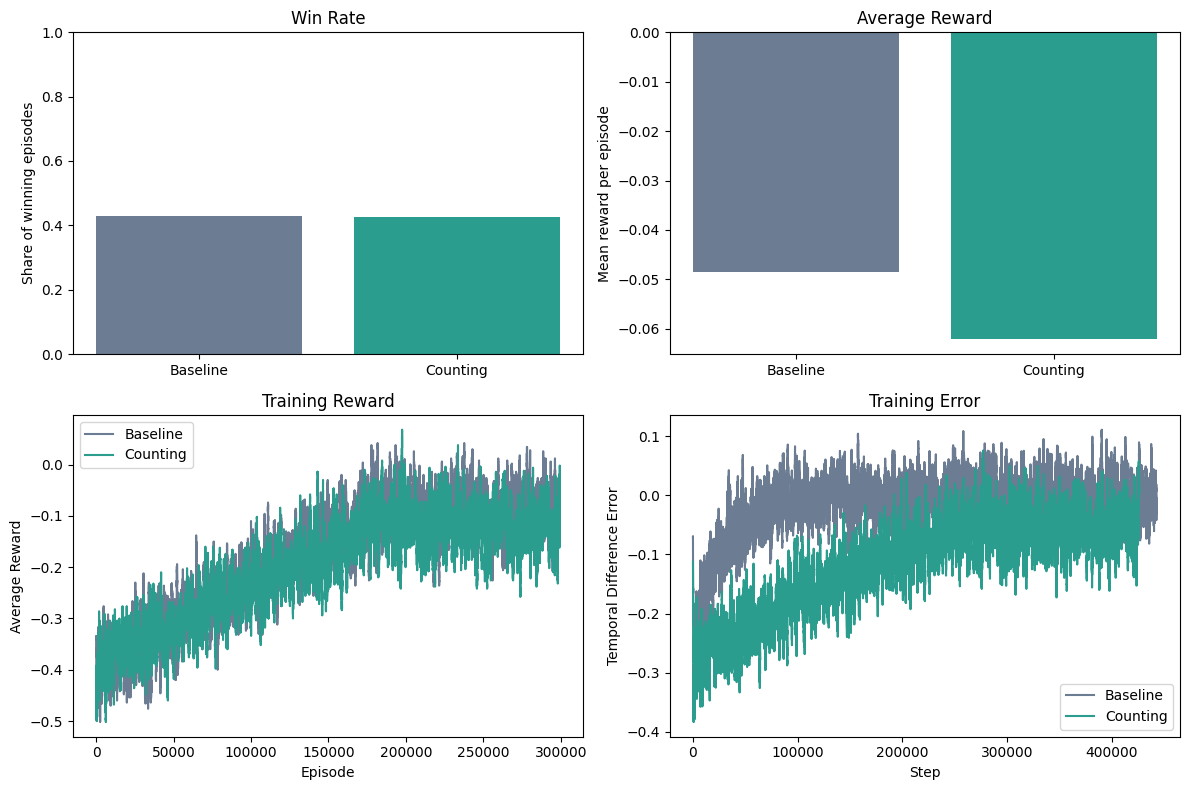

Baseline metrics:
  Win Rate: 43.0%
  Average Reward: -0.049
  Standard Deviation: 0.952

Counting metrics:
  Win Rate: 42.6%
  Average Reward: -0.062
  Standard Deviation: 0.954


In [2]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

labels = ["Baseline", "Counting"]
win_rates = [baseline_metrics["win_rate"], counting_metrics["win_rate"]]
average_rewards = [baseline_metrics["average_reward"], counting_metrics["average_reward"]]

axs[0, 0].bar(labels, win_rates, color=["#6b7c93", "#2a9d8f"])
axs[0, 0].set_title("Win Rate")
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_ylabel("Share of winning episodes")

axs[0, 1].bar(labels, average_rewards, color=["#6b7c93", "#2a9d8f"])
axs[0, 1].set_title("Average Reward")
axs[0, 1].set_ylabel("Mean reward per episode")

rolling_length = 500
baseline_reward_curve = get_moving_avgs(baseline_artifact["episode_returns"], rolling_length, "valid")
counting_reward_curve = get_moving_avgs(counting_artifact["episode_returns"], rolling_length, "valid")

axs[1, 0].plot(range(len(baseline_reward_curve)), baseline_reward_curve, label="Baseline", color="#6b7c93")
axs[1, 0].plot(range(len(counting_reward_curve)), counting_reward_curve, label="Counting", color="#2a9d8f")
axs[1, 0].set_title("Training Reward")
axs[1, 0].set_xlabel("Episode")
axs[1, 0].set_ylabel("Average Reward")
axs[1, 0].legend()

baseline_error_curve = get_moving_avgs(baseline_artifact["training_error"], rolling_length, "same")
counting_error_curve = get_moving_avgs(counting_artifact["training_error"], rolling_length, "same")

axs[1, 1].plot(range(len(baseline_error_curve)), baseline_error_curve, label="Baseline", color="#6b7c93")
axs[1, 1].plot(range(len(counting_error_curve)), counting_error_curve, label="Counting", color="#2a9d8f")
axs[1, 1].set_title("Training Error")
axs[1, 1].set_xlabel("Step")
axs[1, 1].set_ylabel("Temporal Difference Error")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

print("Baseline metrics:")
print(f"  Win Rate: {baseline_metrics['win_rate']:.1%}")
print(f"  Average Reward: {baseline_metrics['average_reward']:.3f}")
print(f"  Standard Deviation: {baseline_metrics['std_reward']:.3f}")
print()
print("Counting metrics:")
print(f"  Win Rate: {counting_metrics['win_rate']:.1%}")
print(f"  Average Reward: {counting_metrics['average_reward']:.3f}")
print(f"  Standard Deviation: {counting_metrics['std_reward']:.3f}")